In [36]:
# Tutorial: https://www.youtube.com/watch?v=kCc8FmEb1nY&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=9

In [1]:
# We always start with a dataset to train on. Let's download the tiny shakespeare dataset
#!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

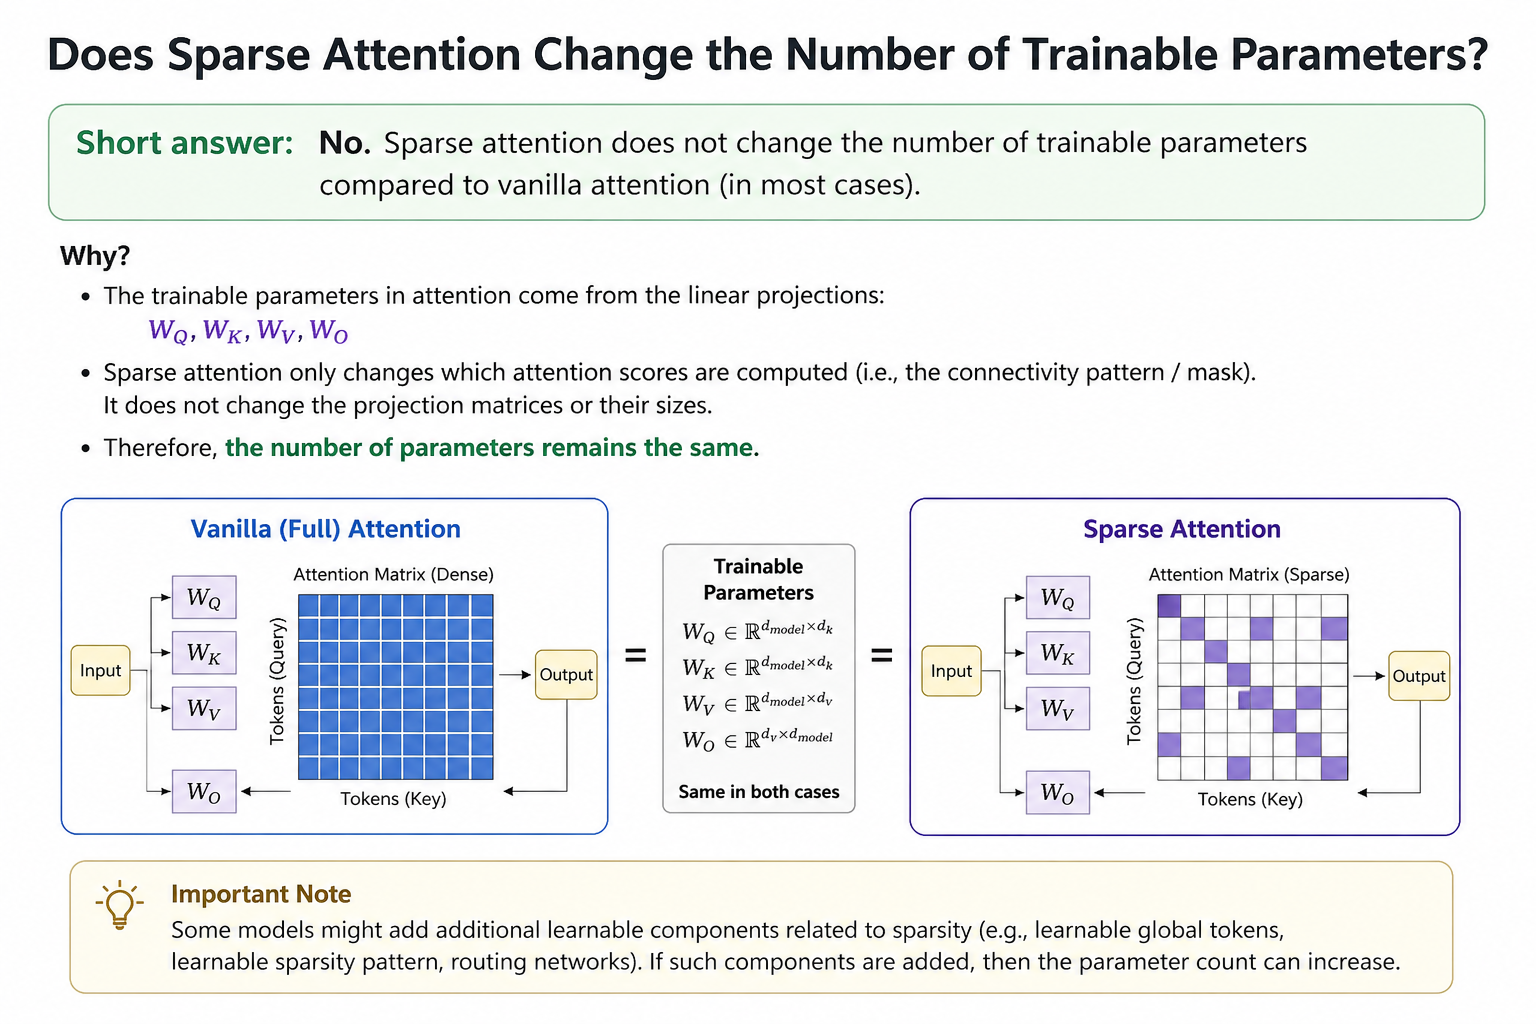

In [4]:
from IPython.display import Image
Image("lwa_attention_details.png")

## If the number of trainable parameters are same then how it speeds up the training process?

> **Speed ≠ number of parameters**
> Speed is dominated by **number of computations**, not how many weights you have.

---

# 1. Where the Cost Actually Comes From

In attention, the expensive part is:

QK^T

If sequence length = **n**:

* You compute **n × n dot products**
* Each dot product ~ O(d)

👉 Total cost:
$[
O(n^2 \cdot d)
]$

---

# 2. What Sparse Attention Changes

Sparse attention **does NOT touch**:

* (W_Q, W_K, W_V, W_O) → parameters unchanged

It only changes:

> **Which entries of (QK^T) you compute**

Instead of full matrix:

* Vanilla → compute all (n^2)
* Sparse → compute only **k per token**

👉 New cost:
$[
O(n \cdot k \cdot d)
]$

Where (k \ll n)

---

# 3. Concrete Example

Let’s say:

* n = 4096 tokens
* d = 64
* k = 64 (local window)

### Full attention:

* 4096² ≈ **16 million interactions**

### Sparse attention:

* 4096 × 64 ≈ **262K interactions**

👉 ~60x fewer computations

---

# 4. Where Speedup Happens

## (A) Compute (FLOPs ↓)

* Fewer dot products
* Less softmax work

## (B) Memory ↓

* Attention matrix smaller
* Less GPU memory pressure

## (C) Better cache efficiency

* Smaller working set

---

# 5. Why Parameters Don’t Matter Much Here

Parameter cost is:

* Linear projections:
  [
  XW_Q, XW_K, XW_V
  ]

Cost:
[
O(n \cdot d^2)
]

👉 This is **linear in n**

---

### Compare:

| Component   | Complexity |
| ----------- | ---------- |
| Projections | O(n d²)    |
| Attention   | O(n² d)    |

👉 For large n:

> **Attention dominates everything**

---

# 6. Key Insight

> Sparse attention speeds things up because it reduces **interaction complexity**, not **model size**

---

# 7. Mental Model

Think of:

* Parameters → *knowledge stored in the brain*
* Attention computation → *number of conversations happening*

Sparse attention:

* Same brain
* Fewer conversations

👉 So faster.

---

# 8. One Subtle Point (Advanced)

Sparse attention only helps if:

* Implemented efficiently (GPU kernels matter)
* Pattern is structured (not random indexing overhead)

Otherwise, theoretical gains may not fully translate.

---

# Final Takeaway

> **Same parameters, fewer computations → faster training**

---

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import sys
sys.path.append("/home/karapathy_trainings/")
# from tokenizer.minbpe.minbpe import BasicTokenizer
import tiktoken
import datetime
import json
import os
import ipdb
get_datetime = lambda x: f"{x.day}_{x.month}_{x.year}_{x.hour}_{x.minute}"

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
device

'cpu'

In [4]:
# tokenizer_ = BasicTokenizer()
# tokenizer_.load("/home/karapathy_trainings/tokenizer/minbpe/bpe_encoding.model")

In [5]:
with open("config/hyperparam.json", "r") as file:
    hyperparams = json.load(file)
    file.close()

In [6]:
# hyperparameters
batch_size = hyperparams.get("batch_size", 8) # how many independent sequences will we process in parallel?
block_size = hyperparams.get("block_size", 100) # what is the maximum context length for predictions?
max_iters = hyperparams.get("max_iters", 100)
eval_interval = hyperparams.get("eval_interval", 500)
learning_rate = hyperparams.get("learning_rate", 0.01)
eval_iters = hyperparams.get("eval_iters", 200)
n_embd = hyperparams.get("n_embd", 768) # should be a number divisible by n_head
n_head = hyperparams.get("n_head", 16) 
n_blocks = hyperparams.get("n_blocks", 8)
dropout = hyperparams.get("dropout", 0.1)
# ------------

In [7]:
device, hyperparams

('cpu',
 {'batch_size': 8,
  'block_size': 32,
  'max_iters': 3000,
  'eval_interval': 100,
  'learning_rate': 0.0001,
  'eval_iters': 200,
  'n_embd': 768,
  'n_head': 4,
  'n_blocks': 6,
  'dropout': 0.3})

In [8]:
torch.manual_seed(1337)

# wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }

encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string


# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/conda/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/conda/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/opt/conda/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.10/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.10/site-packages/ipykernel/

In [9]:
ix = torch.randint(len(data) - block_size, (batch_size,))

In [10]:
ix.shape

torch.Size([8])

In [11]:
len(text)

1115395

In [12]:
# torch.manual_seed(1337)

# # wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
# with open('input.txt', 'r', encoding='utf-8') as f:
#     text = f.read()

# # here are all the unique characters that occur in this text
# vocab = tokenizer_.vocab
# vocab_size = len(vocab)
                 
# # Train and test splits
# #data = torch.tensor(encode(text), dtype=torch.long)

# data = torch.tensor(tokenizer_.encode(text), dtype=torch.long)
# n = int(0.9*len(data)) # first 90% will be train, rest val
# train_data = data[:n]
# val_data = data[n:]

In [13]:
vocab_size

65

In [14]:
def save_model_details(path, hyperparams, model, loss_step_details):
    s = get_datetime(datetime.datetime.now())
    path_ = os.path.join(path,s)
    if not os.path.exists(path_):
        os.makedirs(path_)
    root = path_
    try:
        with open(f"{path_}/hyperparams.json","w") as f:
            json.dump(hyperparams, f)
            f.close()
    except:
        pass
        
    try:
        with open(f"{path_}/loss.json","w") as f:
            json.dump(loss_step_details, f)
            f.close()
    except:
        pass
        
    torch.save(model, f"{path_}/minigpt.model")

In [15]:
# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [16]:
import torch
block_size = 10
i_idx = torch.arange(block_size).unsqueeze(1)   # (T, 1)
j_idx = torch.arange(block_size).unsqueeze(0)   # (1, T)
band  = (j_idx <= i_idx) & ((i_idx - j_idx) < 4)

In [47]:
class Head(nn.Module):
    """ one head of causal local window attention """
    def __init__(self, head_size, window_size):          # CHANGE 1: add window_size param
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.window_size = window_size

        # CHANGE 2: register a banded mask instead of plain tril
        # mask[i,j] = True  means "allowed to attend"
        # condition: j <= i  (causal)  AND  i - j < window_size  (local)
        i_idx = torch.arange(block_size).unsqueeze(1)   # (T, 1)
        j_idx = torch.arange(block_size).unsqueeze(0)   # (1, T)
        band  = (j_idx <= i_idx) & ((i_idx - j_idx) < window_size)
        self.register_buffer('mask', band)               # (block_size, block_size) bool

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)    # (B, T, head_size)
        q = self.query(x)  # (B, T, head_size)

        wei = q @ k.transpose(-2, -1) * C**-0.5         # (B, T, T) — same as before

        # CHANGE 3: use the banded mask (True=keep, False=block)
        wei = wei.masked_fill(~self.mask[:T, :T], float('-inf'))

        wei = F.softmax(wei, dim=-1)

        wei = self.dropout(wei)

        v   = self.value(x)                              # (B, T, head_size)
        out = wei @ v                                    # (B, T, T) @ (B, T, head_size)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size, 4) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x)) # residual connection
        x = x + self.ffwd(self.ln2(x)) # residual connection
        return x

In [48]:
# super simple bigram model
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        #--------------------------------------------------#
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd) #** Learnable Token Embedding
        self.position_embedding_table = nn.Embedding(block_size, n_embd) #** Learnable Positional Encoding
        #--------------------------------------------------#
        
        #-------------- Enters the transformer block ------#
        #self.sa_head = MultiHeadAttention(n_head, n_embd//4) #Head(n_embd)
        #self.ff = FeedFoward(n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_blocks)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)
        #--------------------------------------------------#

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)

        #x = self.sa_head(x)
        #x = self.ff(x)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)
        
        #### No Softmax needed as cross_entropy function in pytorch internally applies
        #### the softmax before loss calculation
        
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            print("****",idx_cond.shape)
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
            #print(idx)
        return idx

In [49]:
model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

42.622529 M parameters


In [23]:
# x, y = get_batch('train')

In [50]:
# x[0:1,:].shape

In [51]:
# m(x[0:1,:])

In [52]:
# x.reshape(shape=(1,8,10))

In [53]:
loss_curve = {}
max_iters = 0

In [20]:
for iter in range(max_iters, max_iters+1000):
    iter_loss_temp = {}
    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()

        iter_loss_temp['train'] = float(f"{losses['train'].item():.4f}")
        iter_loss_temp['val'] = float(f"{losses['val'].item():.4f}")
        loss_curve[iter] = iter_loss_temp 
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
max_iters += 1000

step 0: train loss 4.3592, val loss 4.3572
step 100: train loss 2.4251, val loss 2.4220
step 200: train loss 2.3172, val loss 2.3232
step 300: train loss 2.2191, val loss 2.2344
step 400: train loss 2.1613, val loss 2.1958


KeyboardInterrupt: 

In [ ]:
# loss_curve_ = {}

# for k, v in loss_curve.items():
#     temp = {}
#     for k1, v1 in v.items():
#         temp[k1] = float(f"{v1.item():.4f}")
#         loss_curve_[k] = temp

In [21]:
save_model_details("saved_model_checkpoints",hyperparams,m,loss_curve)

In [20]:
# generate from the model
torch.manual_seed(10)
context = torch.zeros((1, 1), dtype=torch.long
                      , device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))


Loond spet in fim Vimp me-time the, teat frewn, weet sooow no login to so seseeseers'd dand sham,
To. Mask e be we wime thalle a they woued,
Wer go blarth and any with the le eent wuty ndow romenepals faess dious ser;
Tre, ner on sorme in a Ist band magre,
And com se the up to spenconce thumpe,
Tive on sain op, congsIed cien, framese, agat, mabulave!
Wiph, yoand faille, sabbeinl sind;
Bept, thin reat youg fith?

PUMESBES:
Iblome ke de id asee nelce int her thowe will spes: theee swith mark swer unet the on at Wershe ,in:
Awith they le noul meare to an cinsts deare thay?
The sawhing thie whoy tragote stons; me,
Theme consence on groive ist
A stiree kne Go dest pe the passey.

GLARD:
Lin: mer him your yere beavere ansed and thise sper nearsbe neaft sperey oir the too gooow sen, en
un weat thire Wour rou thate perty
Re peapesee hid reade hean thatish,
Any smaid decr thire! with thatt wowe and tham haithy.

BULEY HARY EO:
Ore, seno sirt to nieg and graves,
Roo, note to my ly beay thom on 

### Inference by Loading Saved Model

In [23]:
m_ = torch.load("saved_model_checkpoints/3_11_2024_18_24/minigpt.model")

In [24]:
with open("saved_model_checkpoints/3_11_2024_14_25/hyperparams.json", "r") as file:
    hyperparams = json.load(file)
    file.close()

In [25]:
# hyperparameters
batch_size = hyperparams.get("batch_size", 8) # how many independent sequences will we process in parallel?
block_size = hyperparams.get("block_size", 100) # what is the maximum context length for predictions?
max_iters = hyperparams.get("max_iters", 100)
eval_interval = hyperparams.get("eval_interval", 500)
learning_rate = hyperparams.get("learning_rate", 0.01)
eval_iters = hyperparams.get("eval_iters", 200)
n_embd = hyperparams.get("n_embd", 768) # should be a number divisible by n_head
n_head = hyperparams.get("n_head", 16) 
n_blocks = hyperparams.get("n_blocks", 8)
dropout = hyperparams.get("dropout", 0.1)
# ------------

In [27]:
# generate from the model
#torch.manual_seed(10)
context = torch.zeros((1, 1), dtype=torch.long
                      , device=device)
print(decode(m_.generate(context, max_new_tokens=2000)[0].tolist()))


stry in't.

JUCIO:
Madamuch grow's tieens, a the well is with aidurest
Shand what, much stell ger proud,
And this, wither but I was
That proor mann's dightio, as you ungelyout a son,
What staaist suchorful.
Onr Glo? A dielows thou bannot lord of an woman your wrich meliever;
Ay, bef lie,s, merrants, but wherest of our you I but do word'd
Date did Suntruceds. Some it, are I preace
With coue a nature I, have king, newers on,
Somar.' O in she that word, as may have stand if is succh.

DORD Servose, Landshort of GuOUCESTER:
Thoughost of your a mon:
Here the wrant by everings from onithet, while
entl my not than lad? I thangur'd I know though word fher leart's that I his garainst Tutsendy.

Numpherter:
Unge betcy
Will, my you landed well in Here's save
Tyser brokest.
Come mucio, arroth thand dabe his kess word's nor tead
So of thousandest to devinguur trestemas,
That's by man not Morbasted?

TLEORENTESS OF YORK:
Withat, doway.
With stard,---
And your ventainser,
And them'd you seture, subj

In [28]:
with open("saved_model_checkpoints/3_11_2024_14_25/loss.json", "r") as file:
    loss_curve = json.load(file)
    file.close()

In [32]:
import pandas as pd
loss_df = pd.DataFrame(loss_curve).T

<Axes: >

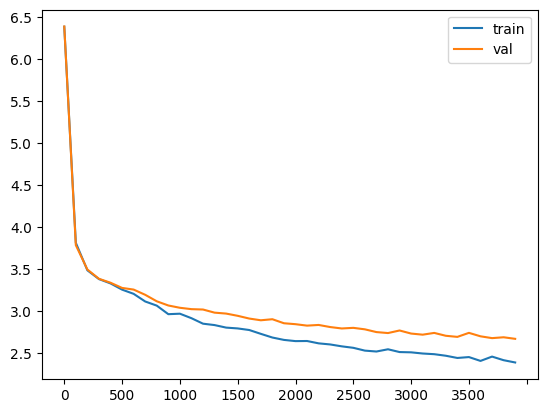

In [33]:
loss_df.plot()